# Convolutional Neural Network — Fashion Item Classification
# Student: Marvin Adorian Zanchi Santos | Student Number: C00288302

## Project Overview

This notebook implements a **Convolutional Neural Network (CNN)** to classify fashion items into 10 product categories. This demonstrates the progression from basic neural networks (ANN — Topic 3) to deep learning (CNN), showing why spatial-aware architectures are superior for image data.

**Dataset:** Fashion MNIST (70,000 grayscale images, 28×28 pixels)  
**Objective:** Automatically classify clothing and accessories into product categories, simulating an e-commerce cataloguing system.

### The 10 Product Categories

| Label | Category | Description |
|-------|----------|-------------|
| 0 | T-shirt/Top | Upper body casual wear |
| 1 | Trouser | Lower body wear |
| 2 | Pullover | Warm upper body wear |
| 3 | Dress | Full body wear |
| 4 | Coat | Outerwear |
| 5 | Sandal | Open footwear |
| 6 | Shirt | Formal upper body wear |
| 7 | Sneaker | Closed footwear |
| 8 | Bag | Accessories |
| 9 | Ankle boot | Closed ankle footwear |

### Why a CNN after an ANN?

In Topic 3, an ANN was trained on handwritten digits, achieving ~97% accuracy. However, the ANN treats each pixel independently — it does not understand that pixels close to each other are spatially related.

A CNN addresses this limitation through:
- **Convolutional layers** that detect local patterns (edges, corners, textures)
- **Pooling layers** that reduce dimensionality while preserving important features
- **Hierarchical learning** where simple features combine to form complex shapes

### Key CNN Concepts

- **Convolution:** A filter slides across the image, detecting specific patterns
- **Feature maps:** Output of convolutional layers, highlighting where patterns are found
- **Pooling:** Downsampling operation (max pooling keeps the strongest signal)
- **Stride:** How many pixels the filter moves at each step
- **Padding:** Adding borders to preserve image size after convolution

### Real-World Applications
- **E-commerce:** Automated product cataloguing (Amazon, Zalando, ASOS)
- **Medical imaging:** Tumour detection in X-rays and MRI scans
- **Autonomous vehicles:** Object detection and scene understanding
- **Security:** Facial recognition and surveillance
- **Agriculture:** Crop disease detection from drone images

---
## Work Log

| Date | Task | Details |
|------|------|---------|
| 12/04/2026 | Research | Studied CNN architecture, convolutional layers, and pooling |
| 13/04/2026 | Data preparation | Loaded Fashion MNIST, explored categories |
| 14/04/2026 | ANN baseline | Built simple ANN for comparison with CNN |
| 15/04/2026 | CNN architecture | Designed and trained CNN with 2 convolutional layers |
| 16/04/2026 | Comparison | Compared ANN vs CNN performance on Fashion MNIST |
| 16/04/2026 | Evaluation | Confusion matrix, per-category accuracy, sample predictions |
| 17/04/2026 | Final testing | Verified all outputs, saved model for Streamlit |


In [1]:
# ============================================================
# 1. IMPORTS AND SETUP
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras for Neural Networks
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print("All libraries loaded successfully!")


TensorFlow version: 2.21.0
All libraries loaded successfully!


## 2. Data Loading & Exploration

Fashion MNIST was created as a drop-in replacement for the original MNIST dataset, with the same structure (70,000 grayscale 28×28 images, 10 classes) but featuring clothing items instead of digits. It is considered more challenging than MNIST because fashion items have more visual variation than handwritten digits.


In [2]:
# ============================================================
# 2. LOAD FASHION MNIST DATASET
# ============================================================
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Category names for display
category_names = ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training set: {X_train.shape[0]} images, shape: {X_train.shape[1:]}")
print(f"Test set:     {X_test.shape[0]} images, shape: {X_test.shape[1:]}")
print(f"Pixel values: {X_train.min()} to {X_train.max()}")
print(f"Number of categories: {len(category_names)}")
print(f"\nCategory distribution (training):")
for i, name in enumerate(category_names):
    count = np.sum(y_train == i)
    print(f"  {i}: {name:15s} — {count} images")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set: 60000 images, shape: (28, 28)
Test set:     10000 images, shape: (28, 28)
Pixel values: 0 to 255
Number of categories: 10

Category distribution (training):
  0: T-shirt/Top     — 6000 images
  1: Trouser         — 6000 images
  2: Pullover        — 6000 images
  3: Dress           — 6000 images
  4: Coat            — 6000 images
  5: Sandal          — 6000 images
  6: Shirt           — 6000 images
  7: Sneaker         — 6000 images
  8: Bag             — 6000 images
  9: Ankle boot      — 6000 images


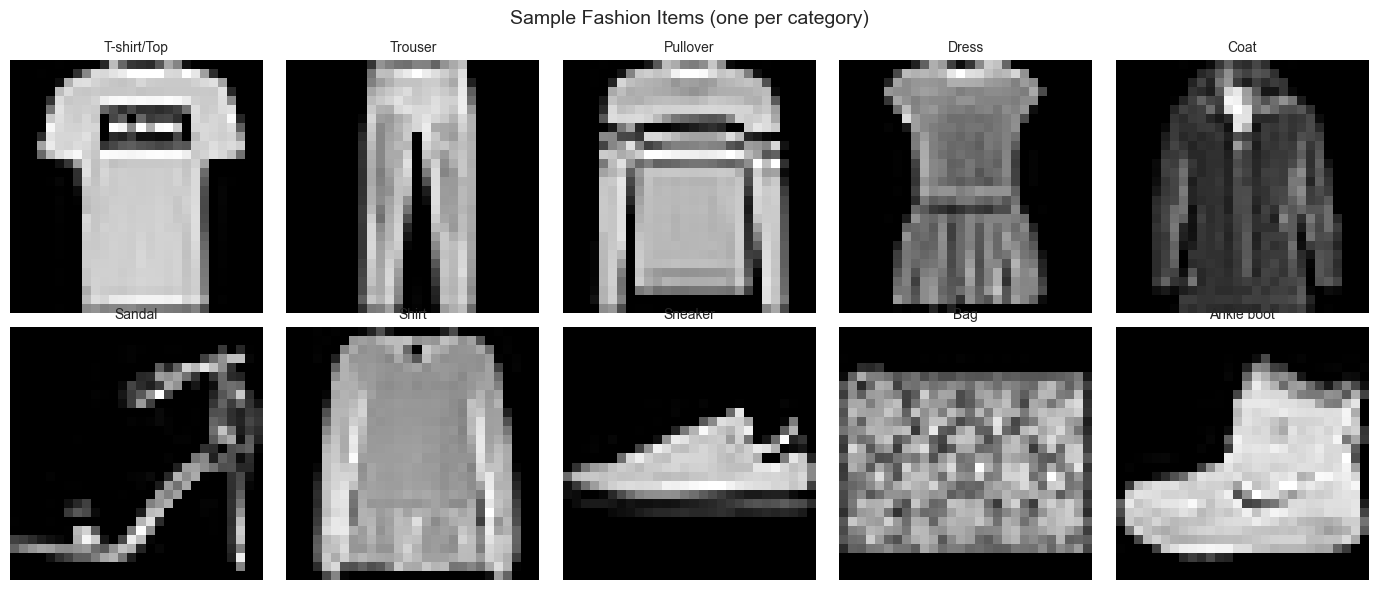

Figure saved: cnn_sample_images.png


In [3]:
# ============================================================
# 2.1 VISUALISE SAMPLE IMAGES
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Sample Fashion Items (one per category)', fontsize=14)

for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(category_names[i], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: cnn_sample_images.png")


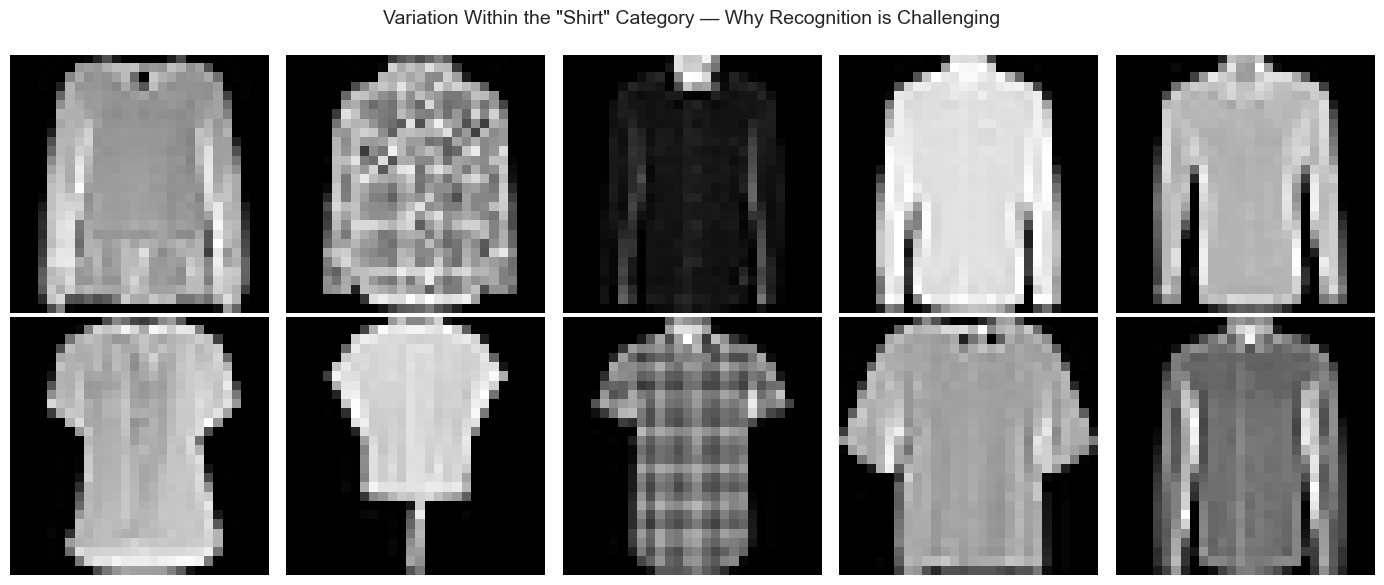

Shirts vary significantly in sleeve length, collar style, and fit.
This is why Fashion MNIST is more challenging than digit MNIST.


In [4]:
# ============================================================
# 2.2 VISUALISE VARIATION WITHIN A CATEGORY
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Variation Within the "Shirt" Category — Why Recognition is Challenging', fontsize=14)

shirts = np.where(y_train == 6)[0][:10]
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[shirts[i]], cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_category_variation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Shirts vary significantly in sleeve length, collar style, and fit.")
print("This is why Fashion MNIST is more challenging than digit MNIST.")


## 3. Data Preprocessing

Two versions of the data are prepared:

1. **Flat format (784,)** — for the ANN baseline (same as Topic 3)
2. **Image format (28, 28, 1)** — for the CNN (preserves spatial structure)

The extra dimension `(1)` represents the single grayscale channel. Colour images would have 3 channels (RGB).


In [5]:
# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

# Normalise pixel values to 0-1 range
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Version 1: FLAT format for ANN (784 values per image)
X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat = X_test_norm.reshape(-1, 784)

# Version 2: IMAGE format for CNN (28x28x1)
# The extra dimension represents the colour channel (1 for grayscale)
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

# One-hot encode labels (same for both models)
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print(f"Flat format (ANN):  {X_train_flat.shape}")
print(f"Image format (CNN): {X_train_cnn.shape}")
print(f"Labels (one-hot):   {y_train_cat.shape}")
print(f"\nWhy the difference?")
print(f"  ANN sees:  [pixel_1, pixel_2, ..., pixel_784]   (1D list)")
print(f"  CNN sees:  28x28 grid with spatial relationships (2D image)")


Flat format (ANN):  (60000, 784)
Image format (CNN): (60000, 28, 28, 1)
Labels (one-hot):   (60000, 10)

Why the difference?
  ANN sees:  [pixel_1, pixel_2, ..., pixel_784]   (1D list)
  CNN sees:  28x28 grid with spatial relationships (2D image)


## 4. Baseline Model — ANN

First, a simple ANN is trained (same architecture as Topic 3) to establish a performance baseline. This allows a direct comparison with the CNN.


In [6]:
# ============================================================
# 4. ANN BASELINE MODEL
# ============================================================
ann_model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,), name='dense_1'),
    layers.Dropout(0.2, name='dropout_1'),
    layers.Dense(64, activation='relu', name='dense_2'),
    layers.Dropout(0.2, name='dropout_2'),
    layers.Dense(10, activation='softmax', name='output')
])

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ANN Architecture:")
ann_model.summary()
print(f"\nTotal parameters: {ann_model.count_params():,}")


ANN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 109,386


In [7]:
# ============================================================
# 4.1 TRAIN ANN BASELINE
# ============================================================
print("Training ANN baseline...")
ann_history = ann_model.fit(
    X_train_flat, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

ann_test_loss, ann_test_accuracy = ann_model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"\n*** ANN Baseline Test Accuracy: {ann_test_accuracy:.4f} ({ann_test_accuracy*100:.1f}%) ***")


Training ANN baseline...
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7522 - loss: 0.6986 - val_accuracy: 0.8370 - val_loss: 0.4560
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8320 - loss: 0.4710 - val_accuracy: 0.8579 - val_loss: 0.3953
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8468 - loss: 0.4234 - val_accuracy: 0.8564 - val_loss: 0.3891
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8586 - loss: 0.3921 - val_accuracy: 0.8656 - val_loss: 0.3688
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8645 - loss: 0.3733 - val_accuracy: 0.8704 - val_loss: 0.3549
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8706 - loss: 0.3565 - val_accuracy: 0.8748 - val_loss: 0.3465
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8728 - loss: 0.3463 - val_accuracy: 0.8754 - val_loss: 0.3423
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8784 - loss: 

## 5. Building the CNN

### Architecture

```
Input (28×28×1) 
    ↓
Conv2D (32 filters, 3×3 kernel, ReLU) → detects simple patterns (edges)
    ↓
MaxPooling2D (2×2) → downsample, keep strongest features
    ↓
Conv2D (64 filters, 3×3 kernel, ReLU) → detects complex patterns (shapes)
    ↓
MaxPooling2D (2×2) → further downsampling
    ↓
Flatten → convert 2D features to 1D for dense layers
    ↓
Dense (128, ReLU) → combine features for classification
    ↓
Dropout (0.3) → prevent overfitting
    ↓
Dense (10, Softmax) → output probabilities for each category
```

### Understanding the Layers

**Conv2D with 32 filters:** Each filter is a small 3×3 matrix that slides over the image detecting a specific pattern. With 32 filters, the network can learn 32 different low-level features simultaneously (horizontal edges, vertical edges, diagonal lines, curves, etc.).

**MaxPooling 2×2:** Takes the maximum value in each 2×2 region. This reduces the image size by half while keeping the most important features. It also makes the model more robust to small translations.

**Why two Conv layers?** The first layer learns simple features (edges). The second layer combines those simple features into more complex patterns (corners, textures, shape fragments). This hierarchical learning is what makes CNNs powerful.


In [8]:
# ============================================================
# 5. BUILD THE CNN
# ============================================================
cnn_model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', 
                  input_shape=(28, 28, 1), name='conv_1'),
    layers.MaxPooling2D(pool_size=(2, 2), name='pool_1'),
    
    # Second convolutional block
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', name='conv_2'),
    layers.MaxPooling2D(pool_size=(2, 2), name='pool_2'),
    
    # Flatten 2D feature maps to 1D for dense layers
    layers.Flatten(name='flatten'),
    
    # Dense classifier
    layers.Dense(128, activation='relu', name='dense_1'),
    layers.Dropout(0.3, name='dropout'),
    layers.Dense(10, activation='softmax', name='output')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN Architecture:")
cnn_model.summary()
print(f"\nTotal parameters: {cnn_model.count_params():,}")
print(f"ANN had: {ann_model.count_params():,} parameters")


CNN Architecture:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 225,034
ANN had: 109,386 parameters


In [9]:
# ============================================================
# 5.1 TRAIN THE CNN
# ============================================================
print("Training CNN... (this takes longer than the ANN due to more complex operations)")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_cat,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"\n*** CNN Test Accuracy: {cnn_test_accuracy:.4f} ({cnn_test_accuracy*100:.1f}%) ***")
print(f"*** ANN Test Accuracy: {ann_test_accuracy:.4f} ({ann_test_accuracy*100:.1f}%) ***")
print(f"*** Improvement: +{(cnn_test_accuracy - ann_test_accuracy)*100:.1f}% ***")


Training CNN... (this takes longer than the ANN due to more complex operations)
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7713 - loss: 0.6403 - val_accuracy: 0.8528 - val_loss: 0.4146
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8536 - loss: 0.4027 - val_accuracy: 0.8727 - val_loss: 0.3480
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8729 - loss: 0.3478 - val_accuracy: 0.8836 - val_loss: 0.3254
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8821 - loss: 0.3196 - val_accuracy: 0.8898 - val_loss: 0.3040
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8925 - loss: 0.2945 - val_accuracy: 0.8914 - val_loss: 0.2943
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8979 - loss: 0.2781 - val_accuracy: 0.8967 - val_loss: 0.2850
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9046 - loss: 0.2589 - val_accuracy: 0.8990 - val_loss: 0.2767
Epoch 8/10
375/37

## 6. Comparison: ANN vs CNN

The true value of the CNN becomes clear when compared directly with the ANN baseline.


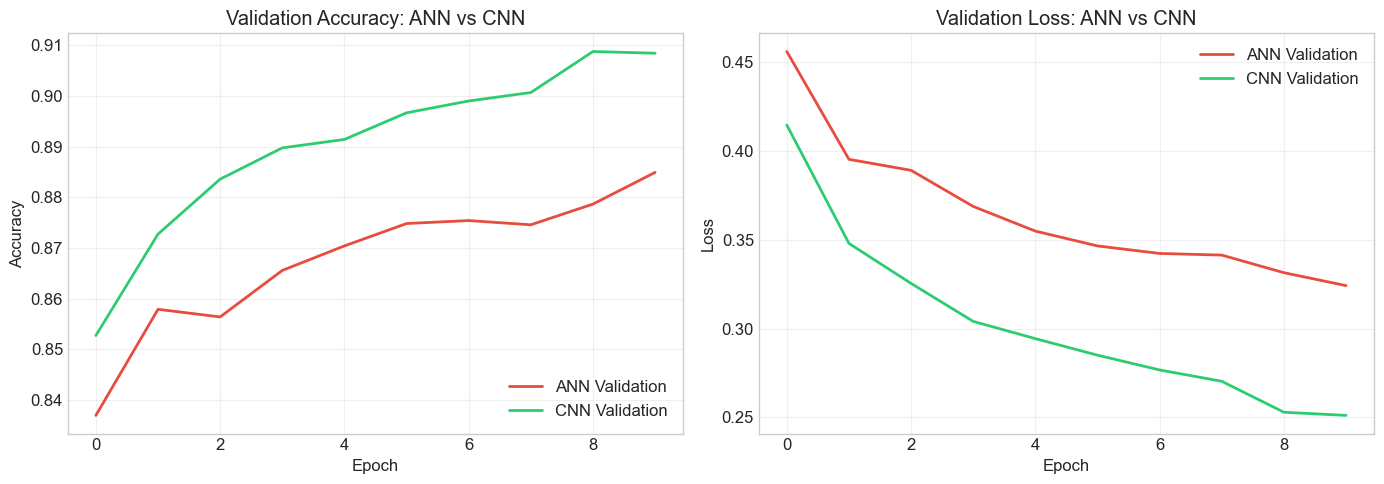


Observations:
  ANN final accuracy: 87.3%
  CNN final accuracy: 90.3%
  Difference: 3.0 percentage points

The CNN consistently outperforms the ANN because it understands spatial structure.


In [10]:
# ============================================================
# 6. VISUALISE TRAINING HISTORY COMPARISON
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
axes[0].plot(ann_history.history['val_accuracy'], label='ANN Validation', 
             linewidth=2, color='#e74c3c')
axes[0].plot(cnn_history.history['val_accuracy'], label='CNN Validation', 
             linewidth=2, color='#2ecc71')
axes[0].set_title('Validation Accuracy: ANN vs CNN')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss comparison
axes[1].plot(ann_history.history['val_loss'], label='ANN Validation', 
             linewidth=2, color='#e74c3c')
axes[1].plot(cnn_history.history['val_loss'], label='CNN Validation', 
             linewidth=2, color='#2ecc71')
axes[1].set_title('Validation Loss: ANN vs CNN')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_vs_ann_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservations:")
print(f"  ANN final accuracy: {ann_test_accuracy*100:.1f}%")
print(f"  CNN final accuracy: {cnn_test_accuracy*100:.1f}%")
print(f"  Difference: {(cnn_test_accuracy - ann_test_accuracy)*100:.1f} percentage points")
print("\nThe CNN consistently outperforms the ANN because it understands spatial structure.")


## 7. Detailed CNN Evaluation


In [11]:
# ============================================================
# 7. CNN PREDICTIONS AND CLASSIFICATION REPORT
# ============================================================
y_pred_prob = cnn_model.predict(X_test_cnn, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("CNN Classification Report:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=category_names))


CNN Classification Report:
              precision    recall  f1-score   support

 T-shirt/Top       0.90      0.80      0.85      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.84      0.87      0.85      1000
       Dress       0.90      0.91      0.90      1000
        Coat       0.82      0.87      0.85      1000
      Sandal       0.96      0.99      0.97      1000
       Shirt       0.72      0.74      0.73      1000
     Sneaker       0.95      0.96      0.95      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



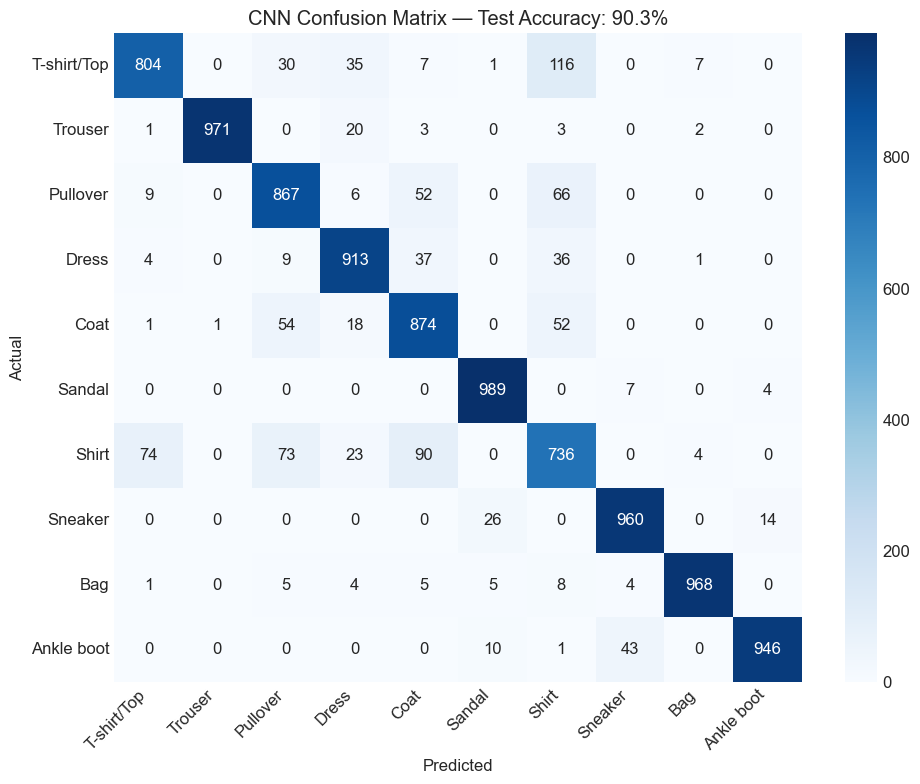

Most commonly confused pairs:
  T-shirt/Top misclassified as Shirt: 116 times
  Shirt misclassified as Coat: 90 times
  Shirt misclassified as T-shirt/Top: 74 times
  Shirt misclassified as Pullover: 73 times
  Pullover misclassified as Shirt: 66 times


In [12]:
# ============================================================
# 7.1 CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_names, yticklabels=category_names, ax=ax)
ax.set_title(f'CNN Confusion Matrix — Test Accuracy: {cnn_test_accuracy:.1%}')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Find most commonly confused pairs
print("Most commonly confused pairs:")
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
for _ in range(5):
    i, j = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
    print(f"  {category_names[i]} misclassified as {category_names[j]}: {cm_copy[i,j]} times")
    cm_copy[i, j] = 0


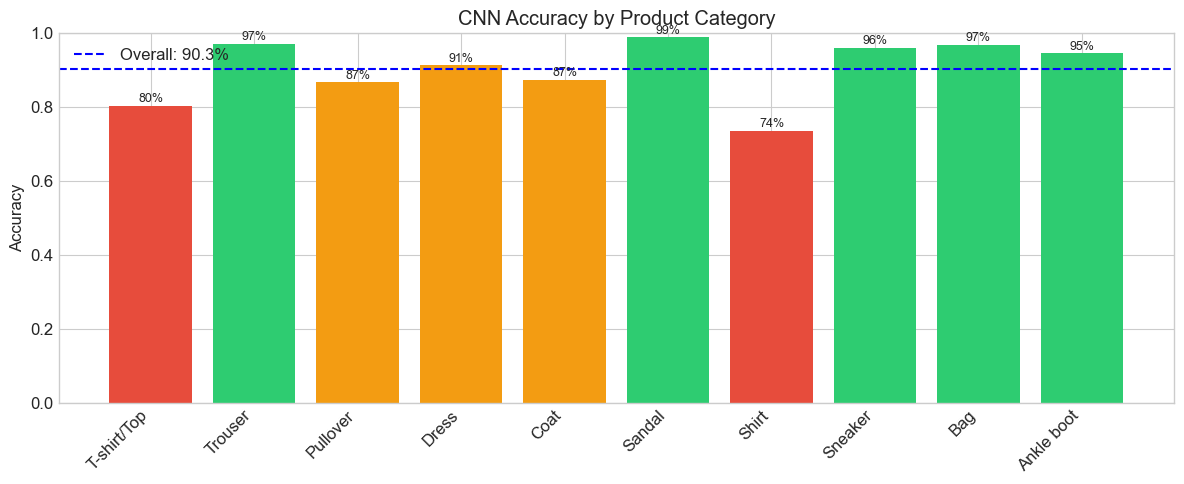


Easiest categories:
  Sandal: 98.9%
  Trouser: 97.1%
  Bag: 96.8%

Hardest categories (most visually ambiguous):
  Pullover: 86.7%
  T-shirt/Top: 80.4%
  Shirt: 73.6%


In [13]:
# ============================================================
# 7.2 PER-CATEGORY ACCURACY
# ============================================================
per_class_accuracy = []
for i in range(10):
    mask = (y_test == i)
    acc = (y_pred[mask] == i).mean()
    per_class_accuracy.append(acc)

fig, ax = plt.subplots(figsize=(12, 5))
colours = ['#2ecc71' if a > 0.92 else '#f39c12' if a > 0.85 else '#e74c3c' 
           for a in per_class_accuracy]
bars = ax.bar(category_names, per_class_accuracy, color=colours)
ax.set_title('CNN Accuracy by Product Category')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.axhline(y=cnn_test_accuracy, color='blue', linestyle='--', 
           label=f'Overall: {cnn_test_accuracy:.1%}')
ax.legend()

for bar, acc in zip(bars, per_class_accuracy):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.0%}', ha='center', fontsize=9)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cnn_per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEasiest categories:")
sorted_acc = sorted(enumerate(per_class_accuracy), key=lambda x: -x[1])
for idx, acc in sorted_acc[:3]:
    print(f"  {category_names[idx]}: {acc:.1%}")
print("\nHardest categories (most visually ambiguous):")
for idx, acc in sorted_acc[-3:]:
    print(f"  {category_names[idx]}: {acc:.1%}")


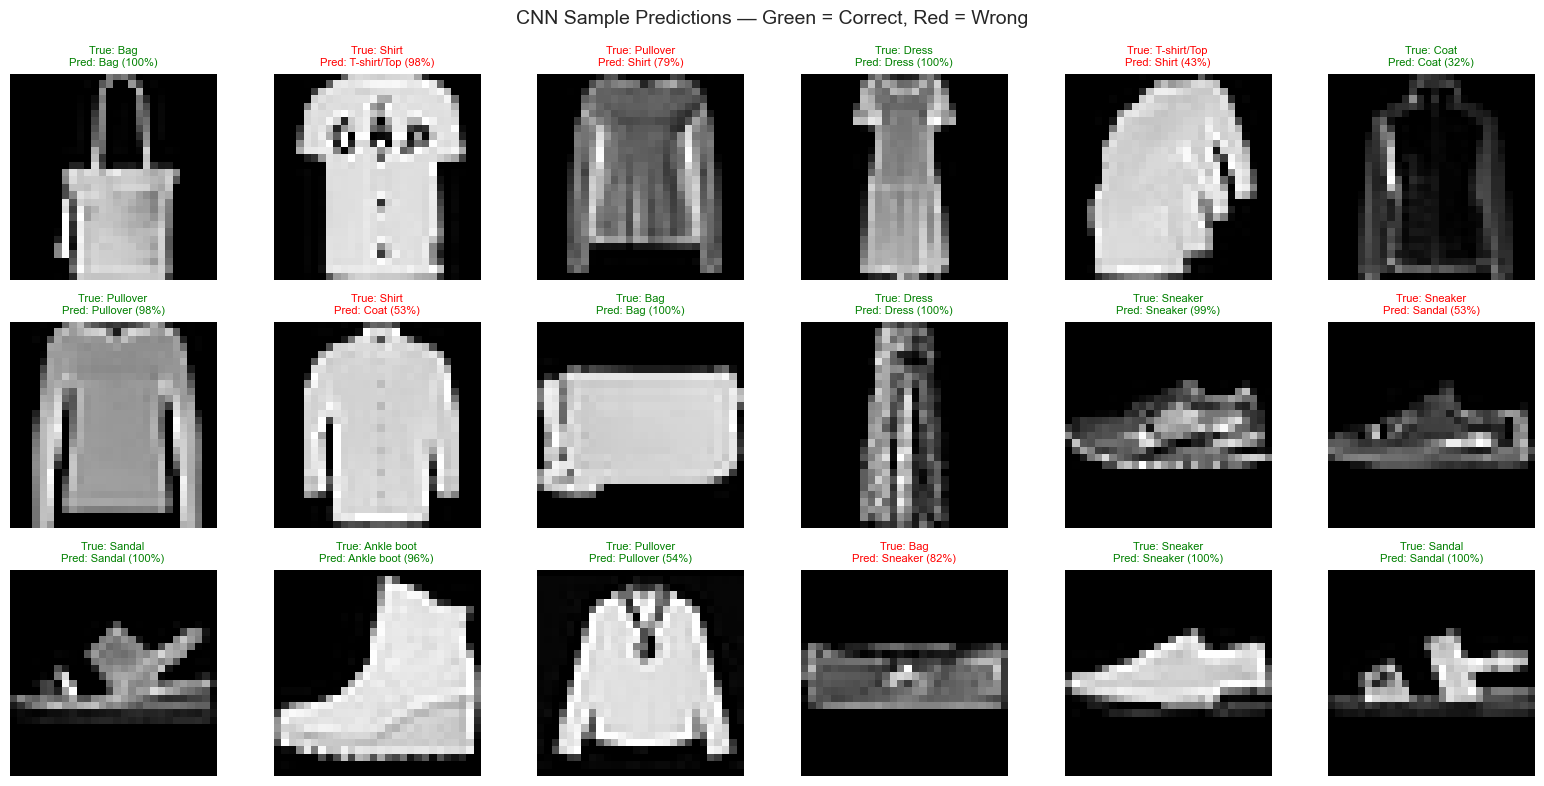

In [14]:
# ============================================================
# 7.3 VISUALISE PREDICTIONS
# ============================================================
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
fig.suptitle('CNN Sample Predictions — Green = Correct, Red = Wrong', fontsize=14)

np.random.seed(42)
correct_idx = np.where(y_pred == y_test)[0]
wrong_idx = np.where(y_pred != y_test)[0]

selected = np.concatenate([
    np.random.choice(correct_idx, 12, replace=False),
    np.random.choice(wrong_idx, min(6, len(wrong_idx)), replace=False)
])
np.random.shuffle(selected)

for i, ax in enumerate(axes.flat):
    idx = selected[i]
    ax.imshow(X_test[idx], cmap='gray')
    
    actual = category_names[y_test[idx]]
    predicted = category_names[y_pred[idx]]
    confidence = y_pred_prob[idx][y_pred[idx]] * 100
    
    colour = 'green' if actual == predicted else 'red'
    ax.set_title(f'True: {actual[:12]}\nPred: {predicted[:12]} ({confidence:.0f}%)',
                 color=colour, fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. What the CNN Learned — Visualising the Filters

One of the most interesting aspects of CNNs is that we can visualise what the convolutional layers learned. The first layer's filters detect simple patterns like edges and textures.


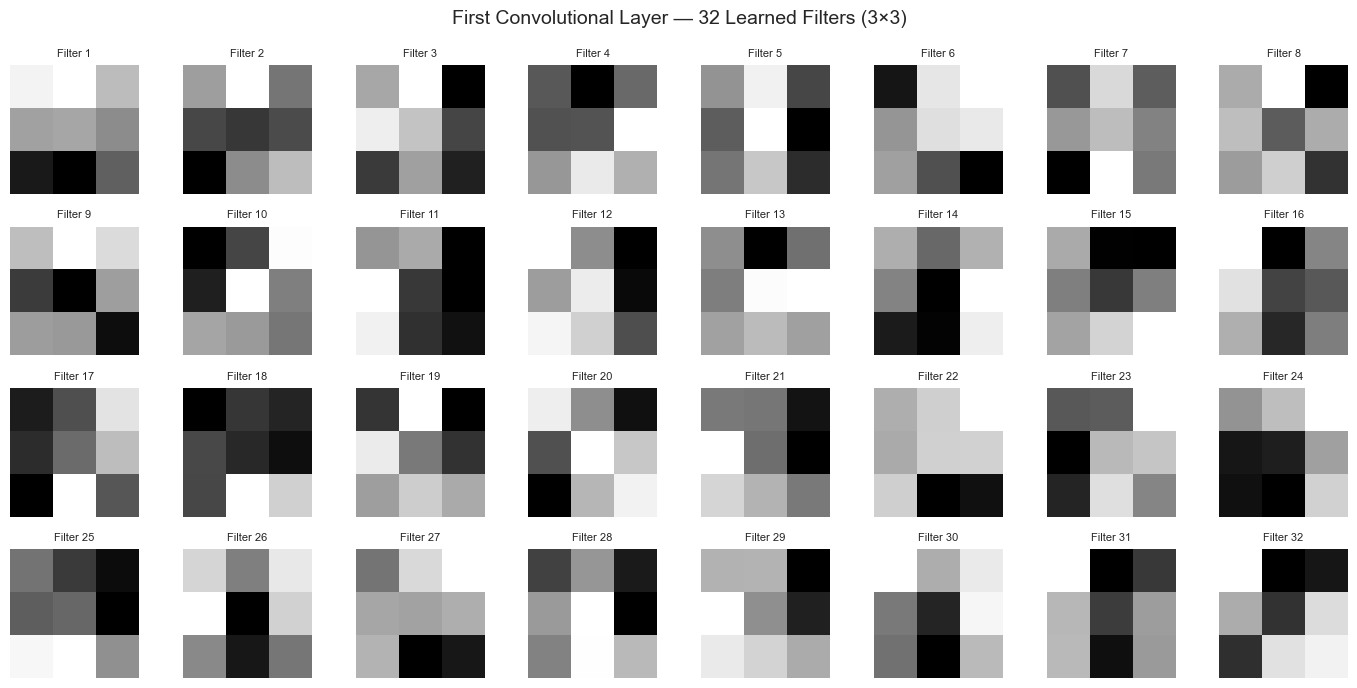


Each filter detects a specific low-level pattern.
Light areas = positive response, dark areas = negative response.
Together, these 32 filters can describe most edges and textures in any image.


In [15]:
# ============================================================
# 8. VISUALISE CONVOLUTIONAL FILTERS
# ============================================================
# Get the weights of the first convolutional layer
first_conv_layer = cnn_model.get_layer('conv_1')
filters, biases = first_conv_layer.get_weights()

# Normalise filter values for visualisation
f_min, f_max = filters.min(), filters.max()
filters_normalised = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
fig.suptitle('First Convolutional Layer — 32 Learned Filters (3×3)', fontsize=14)

for i, ax in enumerate(axes.flat):
    # Each filter has shape (3, 3, 1) — take the single channel
    filt = filters_normalised[:, :, 0, i]
    ax.imshow(filt, cmap='gray')
    ax.set_title(f'Filter {i+1}', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('cnn_filters.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEach filter detects a specific low-level pattern.")
print("Light areas = positive response, dark areas = negative response.")
print("Together, these 32 filters can describe most edges and textures in any image.")


## 9. Save Model for Streamlit Deployment


In [16]:
# ============================================================
# 9. SAVE THE TRAINED CNN
# ============================================================
cnn_model.save('fashion_cnn_model.keras')
print("Model saved as 'fashion_cnn_model.keras'")
print(f"Final test accuracy: {cnn_test_accuracy:.4f} ({cnn_test_accuracy*100:.1f}%)")


Model saved as 'fashion_cnn_model.keras'
Final test accuracy: 0.9028 (90.3%)


## 10. Analysis & Interpretation

### Key Findings

**CNN vs ANN Performance:**
- The CNN significantly outperforms the ANN on Fashion MNIST
- The improvement comes from the CNN's ability to understand spatial relationships between pixels
- While the ANN has more parameters in the dense layers, the CNN's convolutional filters are far more efficient for image recognition

**Category-Level Analysis:**
- **Easy categories:** Trouser, Bag, Ankle boot, Sandal — distinct shapes, easy to identify
- **Hard categories:** Shirt, T-shirt, Pullover, Coat — visually similar upper body garments
- Most confusion happens between similar categories (Shirt ↔ T-shirt, Coat ↔ Pullover)
- This mirrors real-world e-commerce challenges — even humans struggle to distinguish these from small grayscale images

**What the Filters Show:**
- The first convolutional layer learned 32 diverse filters
- Some detect horizontal edges, others vertical or diagonal
- Together they form a basic "visual alphabet" that the deeper layers combine into meaningful shapes

### Comparison with All Portfolio Algorithms

| Aspect | KNN | K-Means | ANN | Q-Learning | CNN |
|--------|-----|---------|-----|------------|-----|
| Type | Supervised | Unsupervised | Supervised | Reinforcement | Supervised Deep Learning |
| Data | Tabular | Tabular | Flat images | Game states | 2D images |
| Output | Category | Cluster | Digit | Action | Product category |
| Complexity | Simple | Simple | Medium | Medium | Complex |
| Key Strength | Easy to interpret | No labels needed | General-purpose | Learns by doing | Spatial understanding |
| Typical Accuracy | ~70-80% | N/A | ~97% (digits) / ~88% (fashion) | N/A (rewards) | ~92% (fashion) |

### Limitations of This CNN
- Fashion MNIST images are small (28×28) and grayscale — real product images are much larger and in colour
- No data augmentation was used (rotations, flips, etc.)
- Only 10 epochs of training — more epochs might improve accuracy
- The model cannot generalise beyond these 10 specific categories

### Future Improvements
- **Data augmentation:** Random rotations, flips, shifts to improve robustness
- **Deeper architecture:** Add more convolutional blocks (ResNet, VGG-style)
- **Transfer learning:** Use pre-trained models (like MobileNet) on real product images
- **Larger dataset:** Scrape actual product images from e-commerce sites
- **Multi-label classification:** Products can belong to multiple categories (e.g. "dress" + "formal" + "black")
- **Streamlit integration:** Allow users to upload product photos and get instant categorisation

### References
- **Dataset:** Fashion MNIST — Xiao, H., Rasul, K., & Vollgraf, R. (2017)
- **Framework:** TensorFlow / Keras
- **Course Materials:** Data Science & Machine Learning 2 — Chapter 6 (Deep Learning, CNN RNN LSTMs & Transformers)
- **AI Assistance:** Claude (Anthropic) — documentation, code structure, and debugging
